# DEU Generative Relativity: Complete Analysis Notebook

This notebook recreates the summary tables and figures used in the manuscript *Generative Relativity in a Triangular DEU Causal Foam*. It is designed for GitHub release.

The notebook is self-contained: it embeds the final summary datasets from the simulation and GW150914 analysis. If full CSV outputs are placed in `data/`, the same plotting cells can be adapted to load those files instead.

Main layers:

1. Baseline finite 2+1D Lorentzian scaling regime.
2. Layer 2 generative lapse from useful-bandwidth drain.
3. Layer 3 refinement-sink null and topology-stitch throat signal.
4. Preliminary GW150914 nonlinear ringdown compression candidate.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook can be run either from the repository root or from notebooks/.
ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (ROOT.parent / 'data').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'data'
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)

def savefig(name):
    for ext in ['png','pdf']:
        plt.savefig(FIG / f'{name}.{ext}', bbox_inches='tight', dpi=220)
    plt.show()

print('ROOT =', ROOT)
print('DATA =', DATA)
print('FIG =', FIG)


ROOT = /mnt/data/deu_gr_manuscript
DATA = /mnt/data/deu_gr_manuscript/data
FIG = /mnt/data/deu_gr_manuscript/figures


## Baseline cap sweep

,cap,dMM,V_slope,Amid_slope,Amax_slope,hmed,hmax
0,128,2.420,2.228,1.059,1.098,13,25
1,256,2.728,2.700,1.786,1.727,13,25
2,512,2.931,2.973,2.106,2.211,12,25
3,1024,3.266,3.249,2.454,2.557,12,25


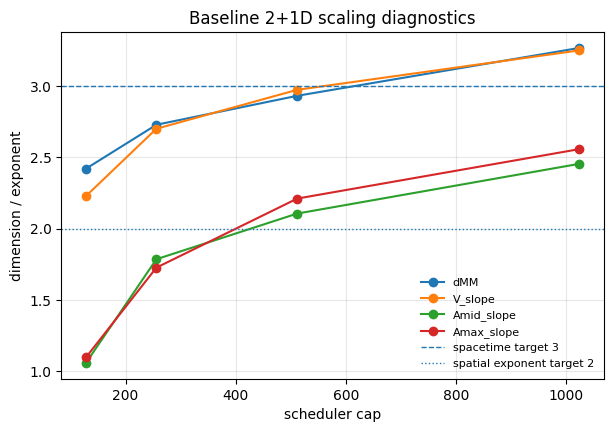

In [2]:

cap_sweep = pd.read_csv(DATA / 'baseline_cap_sweep.csv')
display(cap_sweep)
plt.figure(figsize=(7,4.5))
for col in ['dMM','V_slope','Amid_slope','Amax_slope']:
    plt.plot(cap_sweep['cap'], cap_sweep[col], marker='o', label=col)
plt.axhline(3, linestyle='--', linewidth=1, label='spacetime target 3')
plt.axhline(2, linestyle=':', linewidth=1, label='spatial exponent target 2')
plt.xlabel('scheduler cap')
plt.ylabel('dimension / exponent')
plt.title('Baseline 2+1D scaling diagnostics')
plt.legend(frameon=False, fontsize=8)
plt.grid(True, alpha=0.3)
savefig('nb_baseline_cap_sweep')


## Metric gate and depth replay

,quantity,value
0,weighted_spatial_dimension_median_late,1.907753
1,weighted_fit_r2_median_late,0.996296
2,area_sum_if_split_area_thirds,4.000000


,epoch,faces,depth_min,depth_med,depth_mean,depth_q90,depth_max,area_sum_if_split_area_thirds
0,0,4,0,0,0.000000,0,0,4.0
1,10,66,0,5,4.378788,5,5,4.0
2,20,2050,0,10,9.491220,10,10,4.0
3,30,8014,0,12,11.695408,13,14,4.0
4,40,13678,0,13,12.625603,14,16,4.0
5,50,18808,0,13,13.210655,15,18,4.0
6,52,20004,0,13,13.323535,15,19,4.0


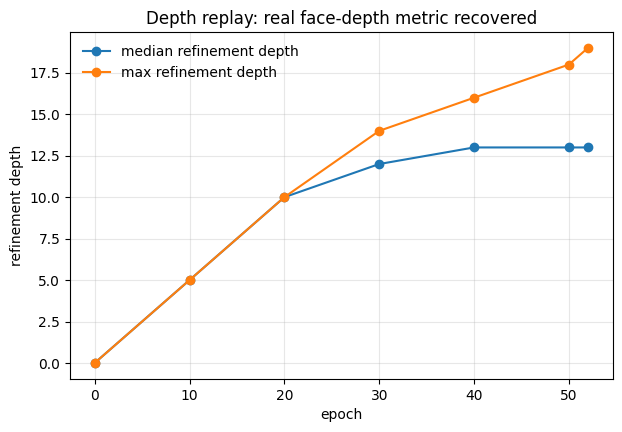

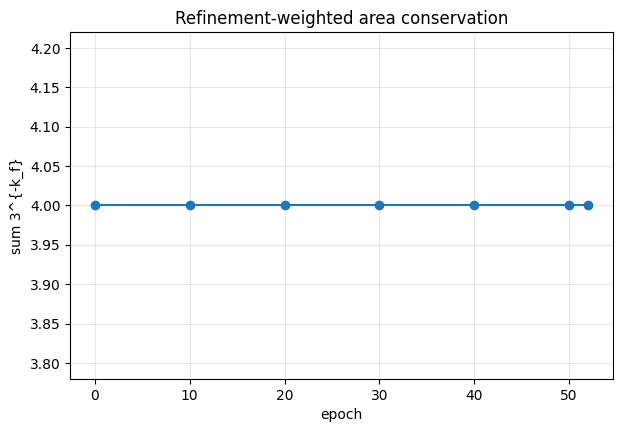

In [3]:

depth_summary = pd.read_csv(DATA / 'depth_summary_cap512_seed101_10k.csv')
metric_gate = pd.read_csv(DATA / 'metric_gate_summary.csv')
display(metric_gate)
display(depth_summary)
plt.figure(figsize=(7,4.5))
plt.plot(depth_summary['epoch'], depth_summary['depth_med'], marker='o', label='median refinement depth')
plt.plot(depth_summary['epoch'], depth_summary['depth_max'], marker='o', label='max refinement depth')
plt.xlabel('epoch')
plt.ylabel('refinement depth')
plt.title('Depth replay: real face-depth metric recovered')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
savefig('nb_depth_replay_depths')
plt.figure(figsize=(7,4.5))
plt.plot(depth_summary['epoch'], depth_summary['area_sum_if_split_area_thirds'], marker='o')
plt.xlabel('epoch')
plt.ylabel('sum 3^{-k_f}')
plt.title('Refinement-weighted area conservation')
plt.grid(True, alpha=0.3)
savefig('nb_area_conservation')


## Layer 2 useful lapse

,run,m_defects,Omega_useful_rate_mean,Omega_useful_rate_sem,positive_frac,forced_defect_splits_mean
0,cap256_3k_5seeds_fixed_target,0,0.000000,0.000000,0.0,0.000000
1,cap256_3k_5seeds_fixed_target,2,0.041373,0.014842,0.8,43.800000
2,cap256_3k_5seeds_fixed_target,4,0.096729,0.012807,1.0,92.000000
3,cap256_3k_5seeds_fixed_target,8,0.178942,0.027313,1.0,198.800000
4,cap512_10k_3seeds_fixed_target,0,0.000000,0.000000,0.0,0.000000
5,cap512_10k_3seeds_fixed_target,4,0.023504,0.006352,1.0,110.666667
6,cap512_10k_3seeds_fixed_target,8,0.064510,0.015726,1.0,230.666667
7,cap512_10k_3seeds_fixed_target,16,0.137962,0.011120,1.0,498.333333
8,cap256_epoch37_5seeds_fixed_epoch,0,0.000000,0.000000,0.0,0.000000
9,cap256_epoch37_5seeds_fixed_epoch,2,0.058829,0.017554,1.0,46.000000


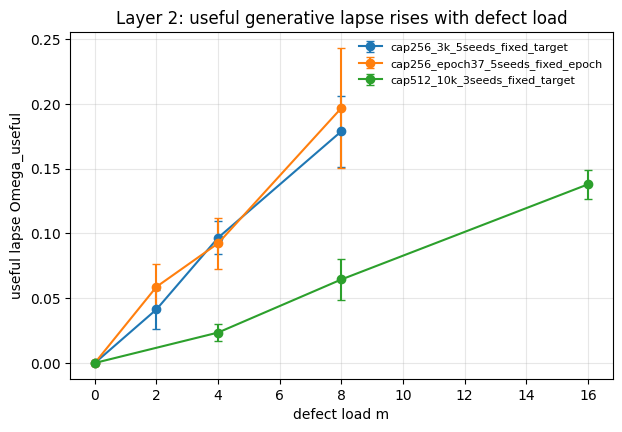

In [4]:

lapse_summary = pd.read_csv(DATA / 'layer2_useful_lapse_summary.csv')
display(lapse_summary)
plt.figure(figsize=(7,4.5))
for run, df in lapse_summary.groupby('run'):
    plt.errorbar(df['m_defects'], df['Omega_useful_rate_mean'], yerr=df['Omega_useful_rate_sem'], marker='o', capsize=3, label=run)
plt.xlabel('defect load m')
plt.ylabel('useful lapse Omega_useful')
plt.title('Layer 2: useful generative lapse rises with defect load')
plt.legend(frameon=False, fontsize=8)
plt.grid(True, alpha=0.3)
savefig('nb_layer2_useful_lapse')


## Layer 2 radial lapse residual

,radial_window,m_defects,seeds,Omega_update_density_mean,Omega_update_global_mean,Omega_update_residual_mean,Omega_update_residual_sem,Omega_update_residual_positive_frac,forced_density_mean,forced_defect_splits_mean,defect_active_faces_final_mean
0,inner_0p15_0p45,0,5,0.000000,0.000000,0.000000,0.000000,0.0,0.0,NaN,53.8
1,inner_0p15_0p45,2,5,0.076341,0.050923,0.025417,0.027670,0.6,0.0,46.0,288.2
2,inner_0p15_0p45,4,5,0.200298,0.135647,0.064651,0.034216,0.8,0.0,91.0,491.8
3,inner_0p15_0p45,8,5,0.328524,0.296071,0.032453,0.015447,0.8,0.0,179.0,902.6
4,mid_0p45_0p90,0,5,0.000000,0.000000,0.000000,0.000000,0.0,0.0,NaN,53.8
5,mid_0p45_0p90,2,5,0.065392,0.050923,0.014469,0.013998,0.8,0.0,46.0,288.2
6,mid_0p45_0p90,4,5,0.080469,0.135647,-0.055179,0.031923,0.2,0.0,91.0,491.8
7,mid_0p45_0p90,8,5,0.263664,0.296071,-0.032408,0.034888,0.4,0.0,179.0,902.6
8,outer_0p90_1p50,0,5,0.000000,0.000000,0.000000,0.000000,0.0,0.0,NaN,53.8
9,outer_0p90_1p50,2,5,0.061820,0.050923,0.010897,0.023500,0.4,0.0,46.0,288.2


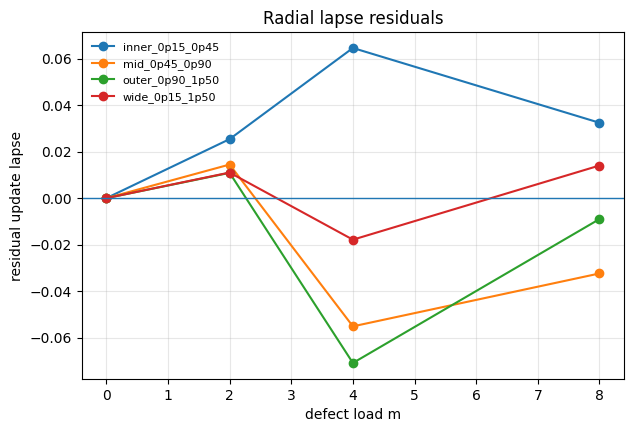

In [5]:

radial_lapse = pd.read_csv(DATA / 'layer2_radial_lapse_residual.csv')
display(radial_lapse)
plt.figure(figsize=(7,4.5))
for window in ['inner_0p15_0p45','mid_0p45_0p90','outer_0p90_1p50','wide_0p15_1p50']:
    df = radial_lapse[radial_lapse['radial_window']==window]
    plt.plot(df['m_defects'], df['Omega_update_residual_mean'], marker='o', label=window)
plt.axhline(0, linewidth=1)
plt.xlabel('defect load m')
plt.ylabel('residual update lapse')
plt.title('Radial lapse residuals')
plt.legend(frameon=False, fontsize=8)
plt.grid(True, alpha=0.3)
savefig('nb_radial_lapse_residual')


## Layer 3 refinement-sink null

,radial_window,m_defects,seeds,median_delta_A_over_R2_mean,median_delta_A_over_R2_sem,A_seed_frac_positive,median_delta_C_mean,median_delta_C_sem,C_seed_frac_positive
0,mid_0p60_1p00,2,5,0.000063,0.000021,0.8,0.000046,0.000045,0.6
1,mid_0p60_1p00,4,5,0.000200,0.000030,1.0,-0.000103,0.000245,0.6
2,mid_0p60_1p00,8,5,0.000133,0.000012,1.0,-0.001168,0.000547,0.2
3,outer_1p00_1p60,2,5,-0.000005,0.000008,0.4,0.000107,0.000417,0.4
4,outer_1p00_1p60,4,5,0.000026,0.000011,1.0,-0.000261,0.000304,0.4
5,outer_1p00_1p60,8,5,0.000013,0.000012,0.4,-0.000215,0.000179,0.2
6,wide_0p25_1p60,2,5,0.000011,0.000014,0.4,-0.000022,0.000307,0.4
7,wide_0p25_1p60,4,5,0.000098,0.000025,1.0,-0.000128,0.000279,0.4
8,wide_0p25_1p60,8,5,0.000063,0.000036,1.0,-0.000191,0.000115,0.2


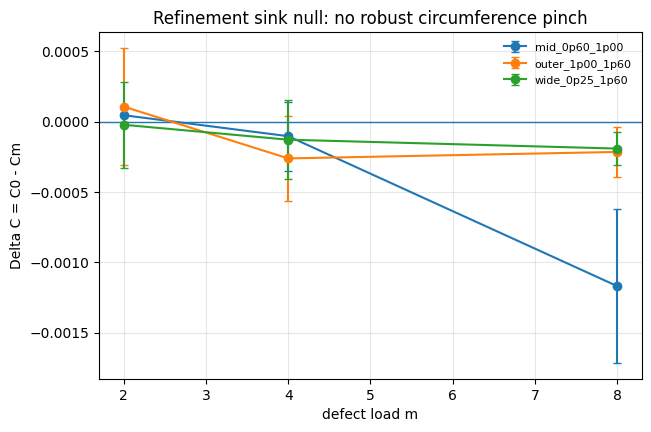

In [6]:

refinement_null = pd.read_csv(DATA / 'layer3_refinement_sink_null.csv')
display(refinement_null)
plt.figure(figsize=(7,4.5))
for window in refinement_null['radial_window'].unique():
    df = refinement_null[refinement_null['radial_window']==window]
    plt.errorbar(df['m_defects'], df['median_delta_C_mean'], yerr=df['median_delta_C_sem'], marker='o', capsize=3, label=window)
plt.axhline(0, linewidth=1)
plt.xlabel('defect load m')
plt.ylabel('Delta C = C0 - Cm')
plt.title('Refinement sink null: no robust circumference pinch')
plt.legend(frameon=False, fontsize=8)
plt.grid(True, alpha=0.3)
savefig('nb_refinement_sink_null_deltaC')


## Layer 3 q-sector positive control

,q_sectors,topological_deficit_units,expected_C_ratio_vs_q6,measured_C_ratio_inner,measured_delta_A_over_R2_outer
0,4,2,0.666667,0.666667,1.140413
1,5,1,0.833333,0.833333,0.570206
2,6,0,1.000000,1.000000,0.000000
3,7,-1,1.166667,1.166667,-0.570206


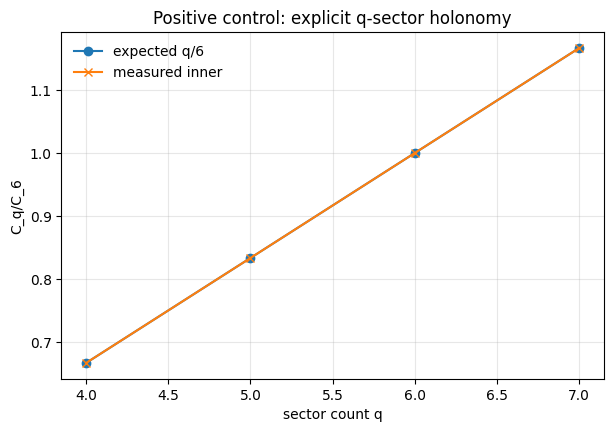

In [7]:

qcontrol = pd.read_csv(DATA / 'layer3_qsector_positive_control.csv')
display(qcontrol)
plt.figure(figsize=(7,4.5))
plt.plot(qcontrol['q_sectors'], qcontrol['expected_C_ratio_vs_q6'], marker='o', label='expected q/6')
plt.plot(qcontrol['q_sectors'], qcontrol['measured_C_ratio_inner'], marker='x', label='measured inner')
plt.xlabel('sector count q')
plt.ylabel('C_q/C_6')
plt.title('Positive control: explicit q-sector holonomy')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
savefig('nb_qsector_positive_control')


## Layer 3 exterior-boundary throat

,verdict,n_core_rows,n_high_rows,n_cone_high_rows,n_throat_high_rows,n_unsupported_high_rows
0,EXTERIOR_BOUNDARY_THROAT_SIGNAL,12,9,0,6,0


,radial_window,m_defects,seeds,support_fraction_used_mean,median_n_faces_annulus_mean,median_n_faces_annulus_m0_mean,median_delta_A_over_R2_mean,A_seed_frac_positive,median_delta_C_mean,C_seed_frac_positive,final_active_faces_mean
0,mid_0p60_1p00,0,3,1.000000,439.000000,439.000000,0.000000,0.0,0.000000,0.000000,20494.666667
1,mid_0p60_1p00,2,3,1.000000,115.333333,439.000000,-0.000876,0.0,0.002700,0.666667,5506.000000
2,mid_0p60_1p00,4,3,1.000000,115.333333,439.000000,-0.000875,0.0,0.002700,0.666667,5637.000000
3,mid_0p60_1p00,8,3,1.000000,115.333333,439.000000,-0.000873,0.0,0.002700,0.666667,5987.000000
4,mid_0p60_1p00,16,3,1.000000,115.333333,439.000000,-0.000873,0.0,0.002700,0.666667,6587.000000
5,outer_1p00_1p60,0,3,1.000000,366.166667,366.166667,0.000000,0.0,0.000000,0.000000,20494.666667
6,outer_1p00_1p60,2,3,0.972222,95.666667,343.833333,-0.000297,0.0,-0.003931,0.333333,5506.000000
7,outer_1p00_1p60,4,3,0.972222,95.666667,343.833333,NaN,NaN,NaN,NaN,5637.000000
8,outer_1p00_1p60,8,3,0.972222,95.666667,343.833333,NaN,NaN,NaN,NaN,5987.000000
9,outer_1p00_1p60,16,3,0.972222,95.666667,343.833333,NaN,NaN,NaN,NaN,6587.000000


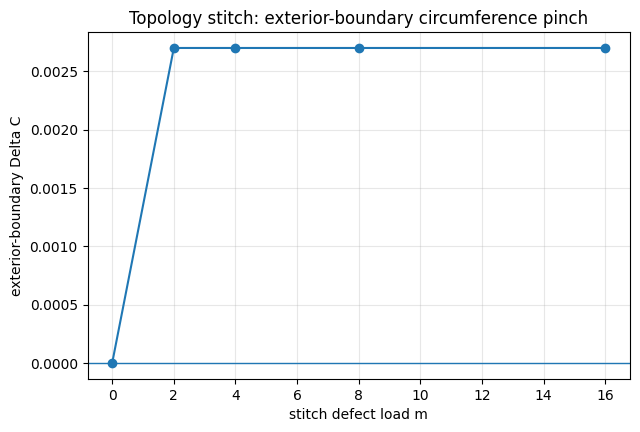

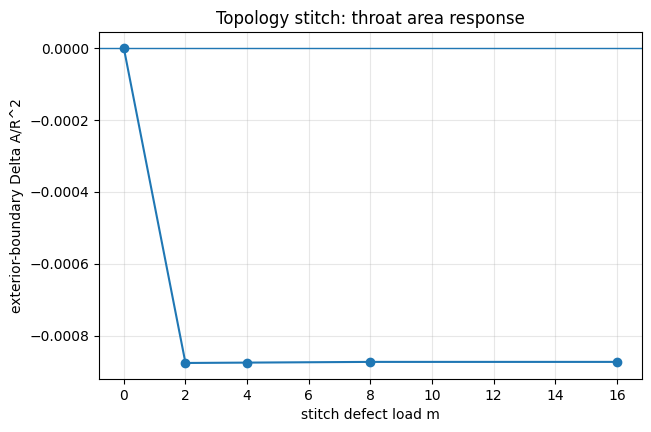

In [8]:

exterior_boundary = pd.read_csv(DATA / 'layer3_exterior_boundary_throat.csv')
throat_verdict = pd.read_csv(DATA / 'layer3_exterior_boundary_throat_verdict.csv')
display(throat_verdict)
display(exterior_boundary)
mid = exterior_boundary[exterior_boundary['radial_window']=='mid_0p60_1p00']
plt.figure(figsize=(7,4.5))
plt.plot(mid['m_defects'], mid['median_delta_C_mean'], marker='o')
plt.axhline(0, linewidth=1)
plt.xlabel('stitch defect load m')
plt.ylabel('exterior-boundary Delta C')
plt.title('Topology stitch: exterior-boundary circumference pinch')
plt.grid(True, alpha=0.3)
savefig('nb_exterior_boundary_deltaC_mid')
plt.figure(figsize=(7,4.5))
plt.plot(mid['m_defects'], mid['median_delta_A_over_R2_mean'], marker='o')
plt.axhline(0, linewidth=1)
plt.xlabel('stitch defect load m')
plt.ylabel('exterior-boundary Delta A/R^2')
plt.title('Topology stitch: throat area response')
plt.grid(True, alpha=0.3)
savefig('nb_exterior_boundary_deltaA_mid')


## LIGO mode ablation

,mode_label,mode_indices,n_modes,delta_BIC_DEU_vs_GR,delta_BIC_UNIFORM_ETA_vs_GR,delta_BIC_FREE_SCALE_vs_GR,delta_BIC_DEU_vs_UNIFORM,delta_BIC_DEU_vs_FREE,p_addone,pass_event_BIC_ge_6,pass_family_p,DEU_beats_uniform,DEU_beats_free
0,modes_0,"(0,)",1,1.343429,1.367675,1.348839,-0.024245,-0.005409,0.183673,False,False,False,False
1,modes_0_1,"(0,1)",2,13.549184,2.601859,10.026530,10.947325,3.522654,0.020408,True,True,True,True
2,modes_0_1_2,"(0,1,2)",3,14.147943,2.038317,12.153527,12.109626,1.994416,0.020408,True,True,True,True
3,modes_0_1_2_3,"(0,1,2,3)",4,8.873913,6.373390,9.144131,2.500524,-0.270218,0.061224,True,False,True,False


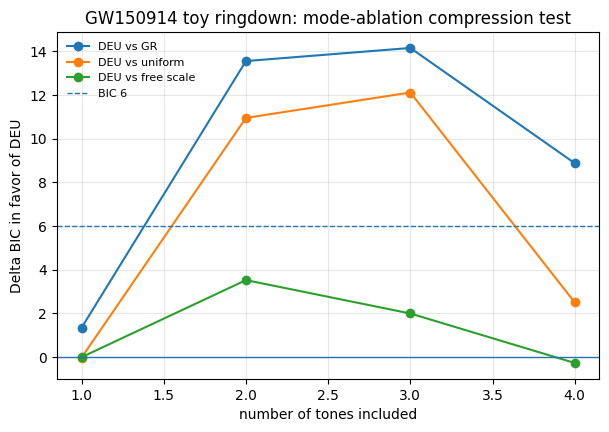

In [9]:

ligo_ablation = pd.read_csv(DATA / 'ligo_mode_ablation_summary.csv')
display(ligo_ablation)
plt.figure(figsize=(7,4.5))
plt.plot(ligo_ablation['n_modes'], ligo_ablation['delta_BIC_DEU_vs_GR'], marker='o', label='DEU vs GR')
plt.plot(ligo_ablation['n_modes'], ligo_ablation['delta_BIC_DEU_vs_UNIFORM'], marker='o', label='DEU vs uniform')
plt.plot(ligo_ablation['n_modes'], ligo_ablation['delta_BIC_DEU_vs_FREE'], marker='o', label='DEU vs free scale')
plt.axhline(0, linewidth=1)
plt.axhline(6, linestyle='--', linewidth=1, label='BIC 6')
plt.xlabel('number of tones included')
plt.ylabel('Delta BIC in favor of DEU')
plt.title('GW150914 toy ringdown: mode-ablation compression test')
plt.legend(frameon=False, fontsize=8)
plt.grid(True, alpha=0.3)
savefig('nb_ligo_mode_ablation')


## LIGO detector consistency

,family_test,event_score,event_best_mode_label,offsource_n,offsource_n_ge_event,p_raw,p_addone
0,plain_max_over_mode_sets,14.147943,modes_0_1_2,48,0,0.0,0.020408
1,strict_max_over_mode_sets_DEU_must_beat_unifor...,14.147943,modes_0_1_2,48,0,0.0,0.020408


,ifo,target_mode_label,delta_BIC_DEU_vs_GR,best_DEU_fc_hz,best_DEU_t0_offset_s,best_DEU_tau_scale,delta_BIC_DEU_vs_UNIFORM,delta_BIC_DEU_vs_FREE,DEU_beats_GR,DEU_beats_uniform,DEU_beats_free
0,H1,modes_0_1_2,1.604176,550.0,0.002,1.0,1.579344,1.350470,True,True,True
1,L1,modes_0_1_2,7.221820,450.0,0.002,1.0,4.313591,-2.541854,True,True,False


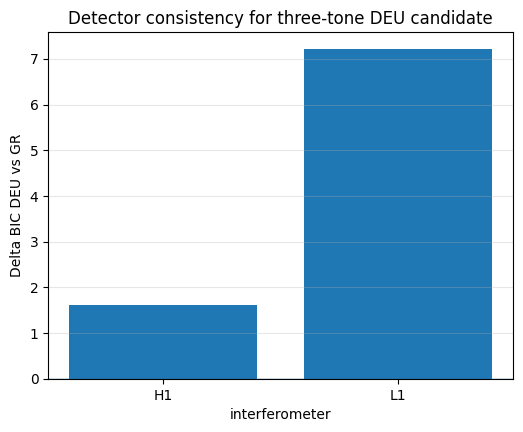

In [10]:

detector_consistency = pd.read_csv(DATA / 'ligo_detector_consistency.csv')
family_summary = pd.read_csv(DATA / 'ligo_family_lookelsewhere_summary.csv')
display(family_summary)
display(detector_consistency)
plt.figure(figsize=(6,4.5))
plt.bar(detector_consistency['ifo'], detector_consistency['delta_BIC_DEU_vs_GR'])
plt.axhline(0, linewidth=1)
plt.xlabel('interferometer')
plt.ylabel('Delta BIC DEU vs GR')
plt.title('Detector consistency for three-tone DEU candidate')
plt.grid(True, axis='y', alpha=0.3)
savefig('nb_ligo_detector_consistency')


## Reanalysis hooks

For full reproduction, place native CSV outputs from the DEU notebooks and the GW150914 search under `data/raw/`, then replace the embedded summaries above with grouped aggregations from those CSVs. The final paper should distinguish embedded-summary reproduction from full raw-run reproduction.
